<a href="https://colab.research.google.com/github/RajrupaDas/DMHalo/blob/main/DMHalo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8') #for better plotting

# **Dataset Loading**

SPARC

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Rotmod_LTG.zip to Rotmod_LTG.zip


In [4]:
import zipfile
import os

zip_path = "Rotmod_LTG.zip"
extract_path = "sparc_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted")

Files extracted


In [5]:
files = os.listdir("sparc_data")
print(len(files))

print(files[:20])

175
['UGC07603_rotmod.dat', 'DDO170_rotmod.dat', 'UGC05005_rotmod.dat', 'NGC1090_rotmod.dat', 'D512-2_rotmod.dat', 'NGC6789_rotmod.dat', 'NGC4085_rotmod.dat', 'NGC4051_rotmod.dat', 'NGC5371_rotmod.dat', 'UGC04305_rotmod.dat', 'UGC07559_rotmod.dat', 'NGC2403_rotmod.dat', 'UGC03580_rotmod.dat', 'UGC07232_rotmod.dat', 'UGC08550_rotmod.dat', 'NGC2998_rotmod.dat', 'UGC00128_rotmod.dat', 'UGC02953_rotmod.dat', 'NGC0247_rotmod.dat', 'UGC07089_rotmod.dat']


**Select Galaxies**

In [6]:
selected_files = [
    "NGC2403_rotmod.dat",
    "NGC3198_rotmod.dat",
    "NGC6503_rotmod.dat",
    "NGC5055_rotmod.dat",
    "NGC2903_rotmod.dat"
]

In [7]:
def load_galaxy(file_path):
    data = []

    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or len(line.strip()) == 0:
                continue
            parts = line.split()
            row = list(map(float, parts[:3]))  # r, v_obs, v_err
            data.append(row)

    data = np.array(data)

    r = data[:, 0]
    v_obs = data[:, 1]

    return r, v_obs

In [8]:
galaxies = {}

for f in selected_files:
    path = os.path.join("sparc_data", f)
    r, v = load_galaxy(path)
    galaxies[f] = (r, v)

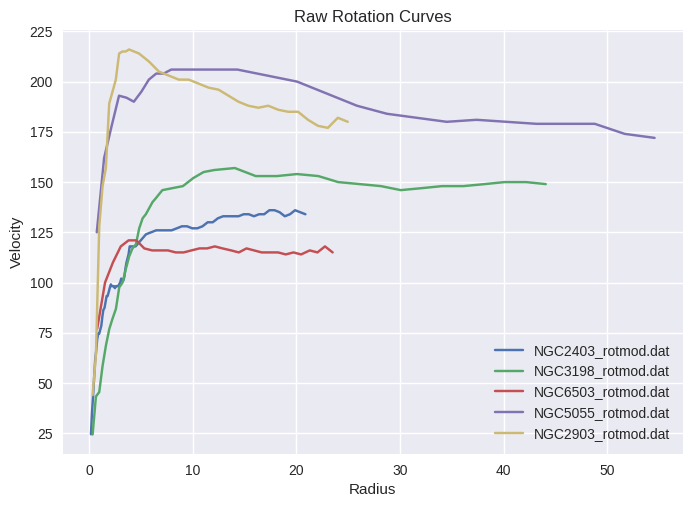

In [9]:
import matplotlib.pyplot as plt

for name, (r, v) in galaxies.items():
    plt.plot(r, v, label=name)

plt.legend()
plt.xlabel("Radius")
plt.ylabel("Velocity")
plt.title("Raw Rotation Curves")
plt.show()

 **Normalize**

In [10]:
def normalize(r, v):
    r_norm = r / np.max(r)
    v_norm = v / np.max(v)
    return r_norm, v_norm

In [11]:
norm_galaxies = {}

for name, (r, v) in galaxies.items():
    r_n, v_n = normalize(r, v)
    norm_galaxies[name] = (r_n, v_n)

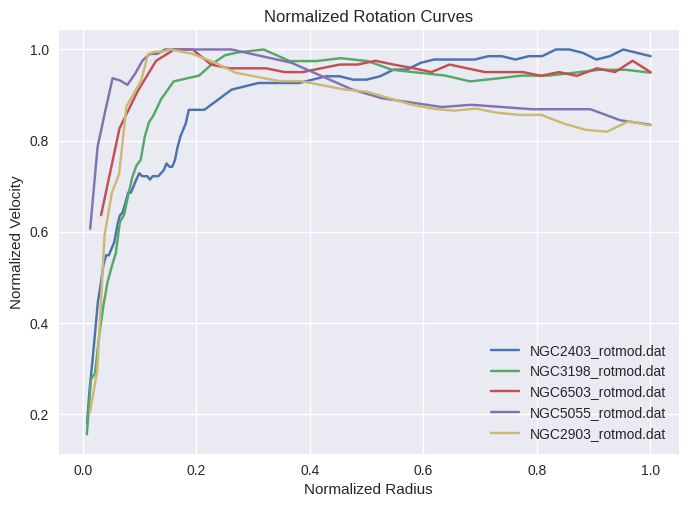

In [12]:
import matplotlib.pyplot as plt

for name, (r, v) in norm_galaxies.items():
    plt.plot(r, v, label=name)

plt.xlabel("Normalized Radius")
plt.ylabel("Normalized Velocity")
plt.legend()
plt.title("Normalized Rotation Curves")
plt.show()

**Interpolate to Fixed Sixe**

In [13]:
def interpolate_curve(r, v, num_points=100):
    r_new = np.linspace(0, 1, num_points)
    v_new = np.interp(r_new, r, v)
    return r_new, v_new

In [14]:
processed_galaxies = {}

for name, (r, v) in norm_galaxies.items():
    r_i, v_i = interpolate_curve(r, v)
    processed_galaxies[name] = (r_i, v_i)

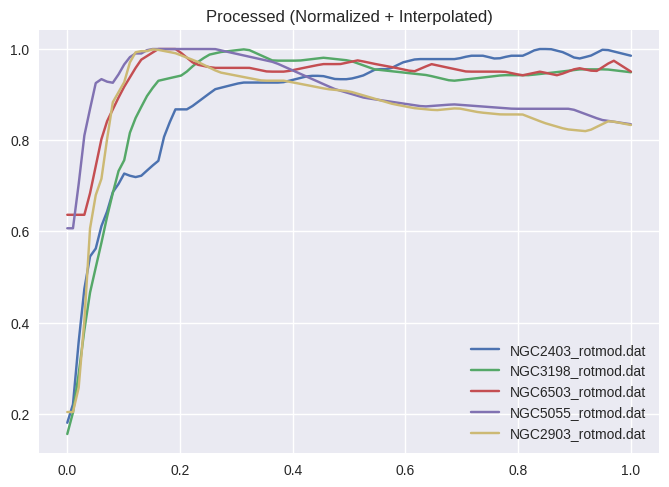

In [15]:
for name, (r, v) in processed_galaxies.items():
    plt.plot(r, v, label=name)

plt.legend()
plt.title("Processed (Normalized + Interpolated)")
plt.show()

**Saving Clean Dataset**

In [16]:
import pandas as pd
import os

os.makedirs("data", exist_ok=True)

for name, (r, v) in processed_galaxies.items():
    clean_name = name.replace("_rotmod.dat", ".csv")

    df = pd.DataFrame({
        "r": r,
        "v_obs": v
    })

    df.to_csv(f"data/{clean_name}", index=False)

In [17]:
df = pd.read_csv("data/NGC2403.csv")
print(df.head())
print(len(df))

          r     v_obs
0  0.000000  0.180147
1  0.010101  0.220495
2  0.020202  0.357516
3  0.030303  0.473888
4  0.040404  0.544954
100


# **NFW Physics Model**

rho_nfw → density profile  
mass_enclosed → M(r)  
velocity_model → v(r)

In [18]:
import numpy as np

G = 1.0 #in normalized units for now

In [19]:
def rho_nfw(r, rs, rho_s):
    x = r / rs
    return rho_s / (x * (1 + x)**2 + 1e-8)

In [20]:
def mass_enclosed(r, rs, rho_s):
    x = r / rs
    return 4 * np.pi * rho_s * rs**3 * (np.log(1 + x) - x / (1 + x))

In [21]:
def velocity_model(r, rs, rho_s):
    M = mass_enclosed(r, rs, rho_s)
    return np.sqrt(G * M / (r + 1e-8))

**Testing Model**

In [22]:
r = np.linspace(0.01, 1, 100) #using normalized radius

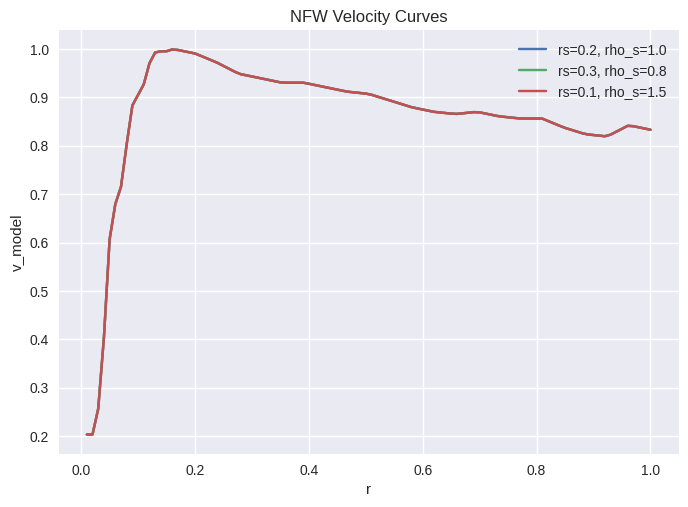

In [23]:
import matplotlib.pyplot as plt

params = [
    (0.2, 1.0),
    (0.3, 0.8),
    (0.1, 1.5)
]

for rs, rho_s in params:
    v_model = velocity_model(r, rs, rho_s)
    v_model = v_model / np.max(v_model)
    plt.plot(r, v, label=f"rs={rs}, rho_s={rho_s}")

plt.xlabel("r")
plt.ylabel("v_model")
plt.title("NFW Velocity Curves")
plt.legend()
plt.show()

r small  → velocity increases

r medium → peaks

r large  → flattens or slowly declines

**Compare With Real Data**

In [24]:
r_obs, v_obs = processed_galaxies["NGC2403_rotmod.dat"]

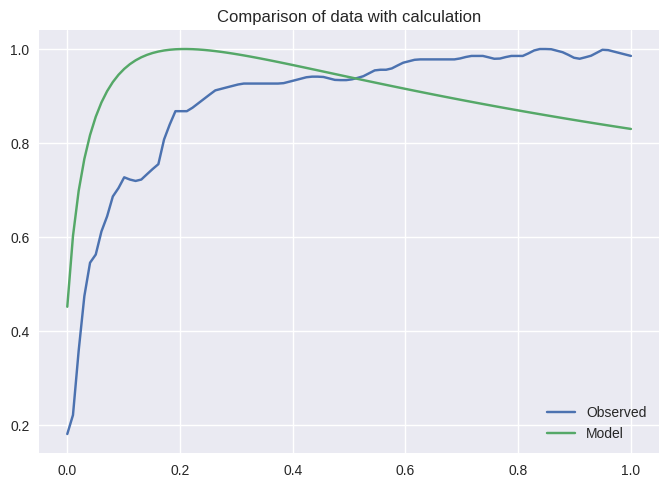

In [25]:
v_model = velocity_model(r, rs, rho_s) #use normalized model
v_model = v_model / np.max(v_model)

plt.plot(r_obs, v_obs, label="Observed")
plt.plot(r_obs, v_model, label="Model")
plt.legend()
plt.title("Comparison of data with calculation")
plt.show()

# **Grid Search**

**MSE Error**

In [26]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

**Grid Setup**

In [27]:
rs_values = np.linspace(0.05, 0.5, 64)
rho_values = np.linspace(0.1, 5, 64)

**Core Grid Search**

In [28]:
def grid_search(r, v_obs):
    best_mse = float('inf')
    best_rs = None
    best_rho = None

    oracle_calls = 0

    for rs in rs_values:
        for rho_s in rho_values:

            v_model = velocity_model(r, rs, rho_s)

            # normalize model (CRUCIAL)
            v_model = v_model / np.max(v_model)

            error = mse(v_obs, v_model)
            oracle_calls += 1

            if error < best_mse:
                best_mse = error
                best_rs = rs
                best_rho = rho_s

    return best_rs, best_rho, best_mse, oracle_calls

**Run on 1 Galaxy**

In [29]:
r, v_obs = processed_galaxies["NGC2403_rotmod.dat"]

best_rs, best_rho, best_mse, calls = grid_search(r, v_obs)

print("Best rs:", best_rs)
print("Best rho_s:", best_rho)
print("MSE:", best_mse)
print("Oracle calls:", calls)

Best rs: 0.35
Best rho_s: 0.7999999999999999
MSE: 0.001000590476900015
Oracle calls: 4096


**Best Fit Graph**

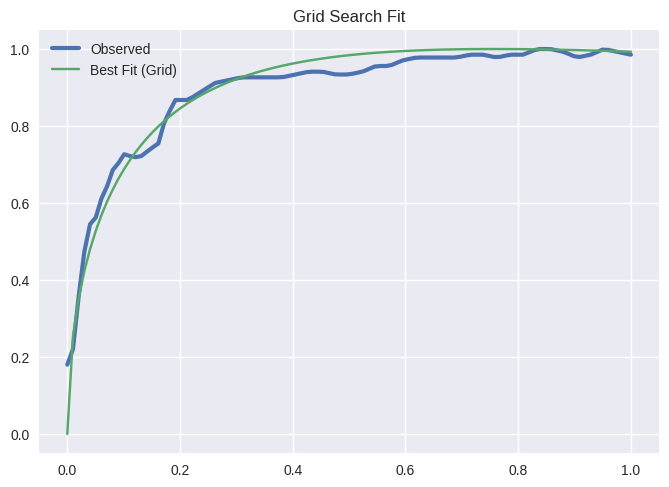

In [30]:
v_best = velocity_model(r, best_rs, best_rho)
v_best = v_best / np.max(v_best)

import matplotlib.pyplot as plt

plt.plot(r, v_obs, label="Observed", linewidth=3)
plt.plot(r, v_best, label="Best Fit (Grid)")
plt.legend()
plt.title("Grid Search Fit")
plt.show()

**Saving Results**

In [31]:
import json
import os

os.makedirs("results", exist_ok=True)

result = {
    "galaxy": "NGC2403",
    "best_rs": float(best_rs),
    "best_rho_s": float(best_rho),
    "mse": float(best_mse),
    "oracle_calls": calls
}

with open("results/grid_NGC2403.json", "w") as f:
    json.dump(result, f, indent=4)

**For All Galaxies**

looping over all since one works

In [33]:
all_results = []

for name, (r, v_obs) in processed_galaxies.items():

    best_rs, best_rho, best_mse, calls = grid_search(r, v_obs)

    all_results.append({
        "galaxy": name,
        "best_rs": float(best_rs),
        "best_rho_s": float(best_rho),
        "mse": float(best_mse),
        "oracle_calls": calls
    })

with open("results/grid_all.json", "w") as f:
    json.dump(all_results, f, indent=4)

# **Gradient Optimization**

**Optimizer**

In [34]:
from scipy.optimize import minimize

**Loss Function**

In [35]:
def loss_fn(params, r, v_obs):
    rs, rho_s = params

    # enforce valid range (important)
    if rs <= 0 or rho_s <= 0:
        return 1e6

    v_model = velocity_model(r, rs, rho_s)

    # normalize (CRUCIAL)
    v_model = v_model / np.max(v_model)

    return np.mean((v_obs - v_model)**2)

**Optimization Wrapper**

In [37]:
def gradient_fit(r, v_obs):

    # initial guess (important)
    init = [0.2, 1.0]

    # bounds to keep search stable
    bounds = [
        (0.05, 0.5),   # rs
        (0.1, 5.0)     # rho_s
    ]

    result = minimize(
        loss_fn,
        init,
        args=(r, v_obs),
        method='L-BFGS-B',
        bounds=bounds
    )

    rs_opt, rho_opt = result.x

    return {
        "rs": float(rs_opt),
        "rho_s": float(rho_opt),
        "mse": float(result.fun),
        "iterations": result.nit,
        "function_calls": result.nfev
    }

**Testing on 1 Galaxy**

In [38]:
r, v_obs = processed_galaxies["NGC2403_rotmod.dat"]

result = gradient_fit(r, v_obs)

print(result)

{'rs': 0.3534414381786121, 'rho_s': 1.0000000043351087, 'mse': 0.0009994736785518287, 'iterations': 6, 'function_calls': 24}


**Plot Fit**

In [163]:
r_final = r.copy()
v_obs_final = v_obs.copy()

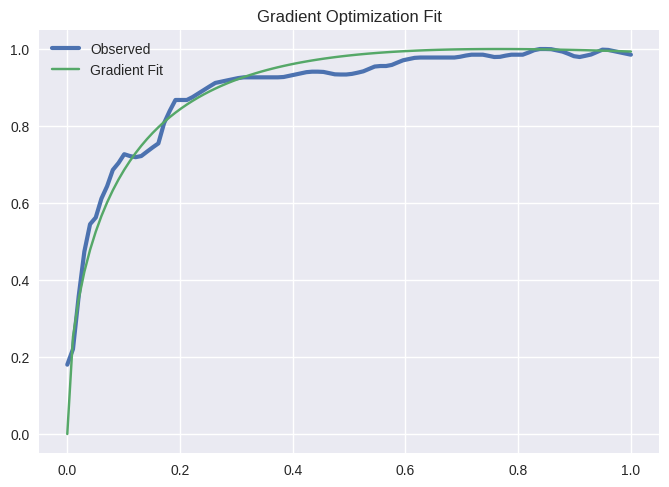

In [39]:
rs = result["rs"]
rho_s = result["rho_s"]

v_fit = velocity_model(r, rs, rho_s)
v_fit = v_fit / np.max(v_fit)

import matplotlib.pyplot as plt

plt.plot(r, v_obs, label="Observed", linewidth=3)
plt.plot(r, v_fit, label="Gradient Fit")
plt.legend()
plt.title("Gradient Optimization Fit")
plt.show()

**for All Galaxies**

In [40]:
grad_results = []

for name, (r, v_obs) in processed_galaxies.items():

    res = gradient_fit(r, v_obs)
    res["galaxy"] = name

    grad_results.append(res)

print(grad_results)

[{'rs': 0.3534414381786121, 'rho_s': 1.0000000043351087, 'mse': 0.0009994736785518287, 'iterations': 6, 'function_calls': 24, 'galaxy': 'NGC2403_rotmod.dat'}, {'rs': 0.23158042028737336, 'rho_s': 1.0000000037424688, 'mse': 0.0020938329000239763, 'iterations': 5, 'function_calls': 18, 'galaxy': 'NGC3198_rotmod.dat'}, {'rs': 0.1430155844215263, 'rho_s': 1.000000000608814, 'mse': 0.005816576855705482, 'iterations': 4, 'function_calls': 18, 'galaxy': 'NGC6503_rotmod.dat'}, {'rs': 0.08742222695132243, 'rho_s': 1.0000000007154821, 'mse': 0.004415088608508712, 'iterations': 3, 'function_calls': 15, 'galaxy': 'NGC5055_rotmod.dat'}, {'rs': 0.10214888892898304, 'rho_s': 0.9999999930640783, 'mse': 0.004772272719618227, 'iterations': 5, 'function_calls': 24, 'galaxy': 'NGC2903_rotmod.dat'}]


**Saving Results**

In [41]:
import json

with open("results/gradient_all.json", "w") as f:
    json.dump(grad_results, f, indent=4)

# **Generating Training data for PINN**

**Defining Sampling Grid**

In [42]:
import numpy as np

r_values = np.linspace(0.01, 1.0, 100)   # avoid 0
rs_values = np.linspace(0.05, 0.5, 50)
rho_values = np.linspace(0.1, 5.0, 50)

**Generate Dataset**

X = (r, rs, rho_s)

y = velocity

In [ ]:
X = []
y = []

for rs in rs_values:
    for rho_s in rho_values:

        v = velocity_model(r_values, rs, rho_s)

        v = v / np.max(v)

        for i in range(len(r_values)):
            X.append([r_values[i], rs, rho_s])
            y.append(v[i])

**Convert to arrays**

In [43]:
X = []
y = []

for rs in rs_values:
    for rho_s in rho_values:

        v = velocity_model(r_values, rs, rho_s)

        v = v / np.max(v)

        for i in range(len(r_values)):
            X.append([r_values[i], rs, rho_s])
            y.append(v[i])

checking shape

In [46]:
import numpy as np

#lists to numpy arrays
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(250000, 3)
(250000,)


**Save Datasets**

In [52]:
np.save("pinn_dataset_X.npy", X)
np.save("pinn_dataset_y.npy", y)

**Test Plot**

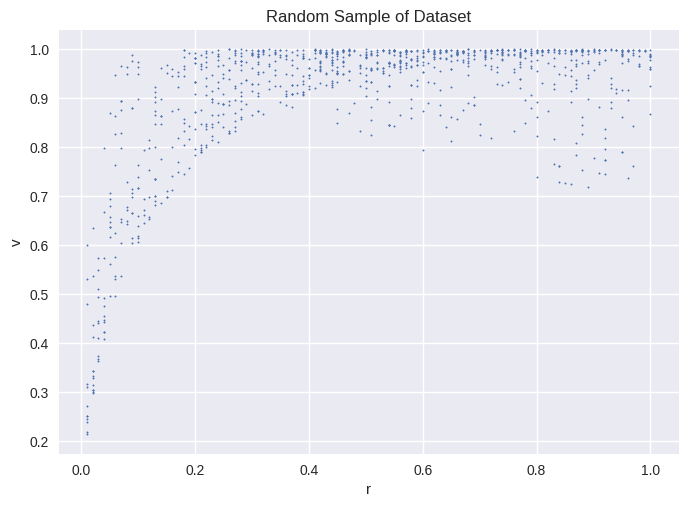

In [54]:
idx = np.random.randint(0, len(X), 1000)

import matplotlib.pyplot as plt

plt.scatter(X[idx, 0], y[idx], s=1)
plt.xlabel("r")
plt.ylabel("v")
plt.title("Random Sample of Dataset")
plt.show()

# **Training Surrogate Model**

In [57]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [58]:
X = np.load("pinn_dataset_X.npy")
y = np.load("pinn_dataset_y.npy")

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

In [59]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=1024, shuffle=True)

**Model Architecture**

In [60]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

**Initial Model**

In [61]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

**Training Loop**

In [62]:
epochs = 100

for epoch in range(epochs):
    total_loss = 0

    for xb, yb in loader:
        pred = model(xb)

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.6f}")

Epoch 0, Loss: 0.030329
Epoch 10, Loss: 0.000055
Epoch 20, Loss: 0.000052
Epoch 30, Loss: 0.000050
Epoch 40, Loss: 0.000029
Epoch 50, Loss: 0.000028
Epoch 60, Loss: 0.000023
Epoch 70, Loss: 0.000025
Epoch 80, Loss: 0.000017
Epoch 90, Loss: 0.000011


In [71]:
torch.save(model.state_dict(), "surrogate.pt")

**Accuracy Check**

In [64]:
r_test = np.linspace(0.01, 1, 100)
rs_test = 0.2
rho_test = 1.0

X_test = np.stack([r_test,
                   np.full_like(r_test, rs_test),
                   np.full_like(r_test, rho_test)], axis=1)

X_test = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    v_pred = model(X_test).numpy().flatten()

v_true = velocity_model(r_test, rs_test, rho_test)
v_true = v_true / np.max(v_true)

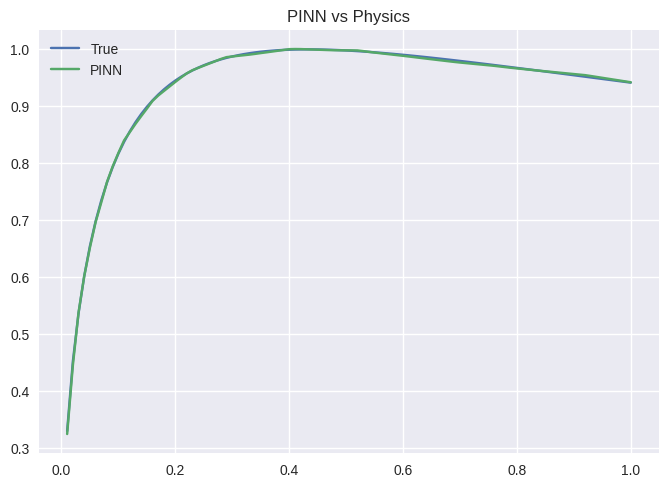

In [65]:
import matplotlib.pyplot as plt

plt.plot(r_test, v_true, label="True")
plt.plot(r_test, v_pred, label="PINN")
plt.legend()
plt.title("PINN vs Physics")
plt.show()

# **Oracle Construction**

**Loading Surrogate**

In [73]:
import torch
import numpy as np

class Surrogate(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Surrogate()
model.load_state_dict(torch.load("surrogate.pt"))
model.eval()

Surrogate(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

**Prepare Input Builder**

In [74]:
def build_input(r, rs, rho_s):
    return np.stack([
        r,
        np.full_like(r, rs),
        np.full_like(r, rho_s)
    ], axis=1)

**Surrogate Prediction**

In [75]:
def predict_velocity(model, r, rs, rho_s):
    X = build_input(r, rs, rho_s)
    X = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        v_pred = model(X).numpy().flatten()

    return v_pred

**MSE Function**

In [76]:
def mse(a, b):
    return np.mean((a - b)**2)

**Oracle Function**

In [77]:
def oracle(model, r, v_obs, rs, rho_s, threshold):

    v_pred = predict_velocity(model, r, rs, rho_s)

    # normalize (CRUCIAL — same pipeline)
    v_pred = v_pred / np.max(v_pred)

    error = mse(v_obs, v_pred)

    if error < threshold:
        return 1   # mark (good candidate)
    else:
        return 0   # not marked

**Setting Threshold** from Grid Search

In [81]:
rs_test = data[0]["best_rs"]
rho_test = data[0]["best_rho_s"]

r, v_obs = processed_galaxies[data[0]["galaxy"]]

v_pred = predict_velocity(model, r, rs_test, rho_test)
v_pred = v_pred / np.max(v_pred)

surrogate_mse = mse(v_obs, v_pred)

threshold = surrogate_mse * 1.05

print("New threshold:", threshold)

New threshold: 0.0056445845465692155


**Testing Oracle**

In [82]:
rs_test = data[0]["best_rs"]
rho_test = data[0]["best_rho_s"]

r, v_obs = processed_galaxies[data[0]["galaxy"]]

print(oracle(model, r, v_obs, rs_test, rho_test, threshold))

1


In [85]:
print(oracle(model, r, v_obs, 0.05, 0.1, threshold))#expected 0

1


**Debugging**

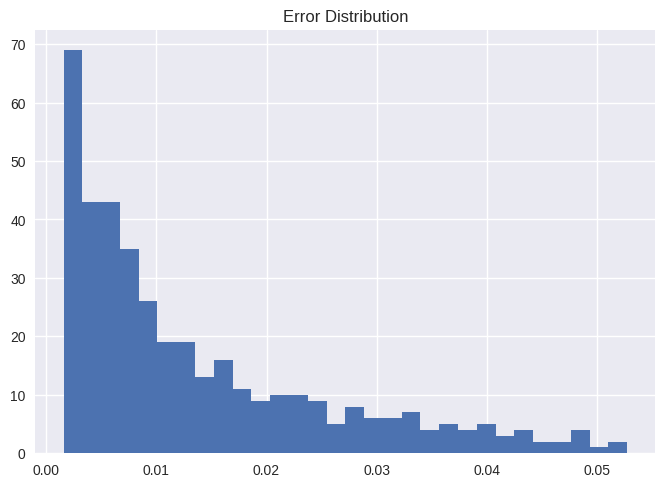

In [86]:
errors = []

for rs in np.linspace(0.05, 0.5, 20):
    for rho in np.linspace(0.1, 5, 20):
        v_pred = predict_velocity(model, r, rs, rho)
        v_pred = v_pred / np.max(v_pred)
        err = mse(v_obs, v_pred)
        errors.append(err)

import matplotlib.pyplot as plt
plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.show()

**Use Percentile-Based Threshold**

In [87]:
threshold = np.percentile(errors, 5)  #top 5% best candidates

In [91]:
# compute all errors
candidates = []
errors = []

for rs in np.linspace(0.05, 0.5, 20):
    for rho in np.linspace(0.1, 5, 20):
        v_pred = predict_velocity(model, r, rs, rho)
        v_pred = v_pred / np.max(v_pred)
        err = mse(v_obs, v_pred)

        candidates.append((rs, rho))
        errors.append(err)

# find best
min_err = min(errors)

# new threshold (very tight)
threshold = min_err * 1.02

In [93]:
rs_grid = np.linspace(0.05, 0.5, 20)
rho_grid = np.linspace(0.1, 5, 20)

candidates = []
errors = []

for rs in rs_grid:
    for rho in rho_grid:
        v_pred = predict_velocity(model, r, rs, rho)
        v_pred = v_pred / np.max(v_pred)
        err = mse(v_obs, v_pred)

        candidates.append((rs, rho))
        errors.append(err)

In [94]:
min_err = min(errors)
best_idx = np.argmin(errors)
best_candidate = candidates[best_idx]

print("Best (surrogate):", best_candidate)
print("Min error:", min_err)

Best (surrogate): (np.float64(0.05), np.float64(1.3894736842105266))
Min error: 0.0015907687474561408


In [95]:
threshold = min_err * 1.02  # 2% tolerance
print("Threshold:", threshold)

Threshold: 0.0016225841224052637


In [96]:
def oracle_fixed(rs, rho):
    v_pred = predict_velocity(model, r, rs, rho)
    v_pred = v_pred / np.max(v_pred)
    err = mse(v_obs, v_pred)

    return 1 if err <= threshold else 0

In [97]:
# best candidate (should be 1)
print("Best candidate test:", oracle_fixed(*best_candidate))

# clearly bad candidate
print("Bad candidate test:", oracle_fixed(0.05, 0.1))

Best candidate test: 1
Bad candidate test: 0


In [98]:
count = 0
marked = []

for (rs, rho), err in zip(candidates, errors):
    if err <= threshold:
        count += 1
        marked.append((rs, rho))

print("Marked count:", count)
print("Marked candidates:", marked[:5])  # preview

Marked count: 3
Marked candidates: [(np.float64(0.05), np.float64(1.1315789473684212)), (np.float64(0.05), np.float64(1.3894736842105266)), (np.float64(0.05), np.float64(1.6473684210526318))]


#**Grover Search**

(rs_index, rho_index) ↔ integer (0–4095)

In [ ]:
rs_grid = np.linspace(0.05, 0.5, 64)
rho_grid = np.linspace(0.1, 5, 64)

def index_to_params(idx):
    i = idx // 64
    j = idx % 64
    return rs_grid[i], rho_grid[j]

def params_to_index(i, j):
    return i * 64 + j

**Building Marked States**

In [ ]:
marked_indices = []

for i, rs in enumerate(rs_grid):
    for j, rho in enumerate(rho_grid):

        if oracle_fixed(rs, rho):   # your working oracle
            idx = params_to_index(i, j)
            marked_indices.append(idx)

print("Marked:", len(marked_indices))

In [100]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.7 MB/s eta 0:00:00


In [101]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit.library import MCXGate
import numpy as np

**Oracle Circuit**

In [102]:
def oracle_circuit(n_qubits, marked_indices):
    qc = QuantumCircuit(n_qubits)

    for idx in marked_indices:
        binary = format(idx, f'0{n_qubits}b')

        # apply X to match state
        for i, bit in enumerate(binary):
            if bit == '0':
                qc.x(i)

        # multi-controlled Z
        qc.h(n_qubits - 1)
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
        qc.h(n_qubits - 1)

        # undo X
        for i, bit in enumerate(binary):
            if bit == '0':
                qc.x(i)

    return qc

**Diffusion Operator**

In [103]:
def diffusion(n_qubits):
    qc = QuantumCircuit(n_qubits)

    qc.h(range(n_qubits))
    qc.x(range(n_qubits))

    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    qc.x(range(n_qubits))
    qc.h(range(n_qubits))

    return qc

In [106]:
rs_grid = np.linspace(0.05, 0.5, 64)
rho_grid = np.linspace(0.1, 5, 64)

def params_to_index(i, j):
    return i * 64 + j

marked_indices = []

for i, rs in enumerate(rs_grid):
    for j, rho in enumerate(rho_grid):
        if oracle_fixed(rs, rho):   # your working oracle
            idx = params_to_index(i, j)
            marked_indices.append(idx)

print("Marked states:", len(marked_indices))

Marked states: 15


**Full Grover Circuit**

In [107]:
n_qubits = 12
qc = QuantumCircuit(n_qubits, n_qubits)

# superposition
qc.h(range(n_qubits))

oracle = oracle_circuit(n_qubits, marked_indices)
diff = diffusion(n_qubits)

k = 50   # ~ π/4 * sqrt(4096)

for _ in range(k):
    qc.compose(oracle, inplace=True)
    qc.compose(diff, inplace=True)

qc.measure(range(n_qubits), range(n_qubits))

In [108]:
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)

{'000010011011': 1, '101001101101': 1, '000100001010': 2, '111001001001': 1, '001110000100': 1, '110111001000': 1, '101010100110': 1, '100010110111': 1, '110111101010': 1, '101111110011': 1, '000110011111': 1, '001011010011': 1, '111110110011': 1, '011101001000': 1, '000001011000': 1, '110110111110': 1, '010111000110': 1, '111111100110': 1, '111010001100': 1, '010111100100': 1, '010111000001': 1, '010101111111': 1, '010000010100': 1, '001101001100': 1, '001000010000': 2, '110000010010': 1, '001000110000': 1, '010110110101': 1, '001101000000': 1, '001100010110': 1, '101011110001': 1, '100010000000': 3, '110101000001': 1, '110000001110': 1, '101010011010': 1, '101111010110': 1, '011100101010': 1, '110010010001': 1, '101111110001': 1, '000111111100': 1, '010010001101': 1, '000110110101': 2, '111110000100': 2, '110000101001': 1, '000111101101': 1, '011000110100': 1, '110001101101': 1, '111101000010': 1, '110010000111': 1, '111100000101': 1, '110010001110': 1, '111011111101': 1, '1111001111

In [110]:
rs_grid = np.linspace(0.05, 0.5, 64)
rho_grid = np.linspace(0.1, 5, 64)

def index_to_params(idx):
    i = idx // 64
    j = idx % 64
    return rs_grid[i], rho_grid[j]

In [111]:
best_state = max(counts, key=counts.get)
best_index = int(best_state, 2)

rs_grover, rho_grover = index_to_params(best_index)

print("Grover result:", rs_grover, rho_grover)

Grover result: 0.47857142857142854 0.1


In [113]:
oracle_calls = k
print(oracle_calls)

50


#**Scaling Experiment**

In [117]:
from scipy.optimize import minimize
import numpy as np

def loss_fn_np(params, r, v_obs):
    rs, rho_s = params

    if rs <= 0 or rho_s <= 0:
        return 1e6

    v_model = velocity_model(r, rs, rho_s)
    v_model = v_model / np.max(v_model)

    return np.mean((v_obs - v_model)**2)

def gradient_fit(r, v_obs):

    init = [0.2, 1.0]

    bounds = [
        (0.05, 0.5),
        (0.1, 5.0)
    ]

    result = minimize(
        loss_fn_np,
        init,
        args=(r, v_obs),
        method='L-BFGS-B',
        bounds=bounds
    )

    return {
        "rs": float(result.x[0]),
        "rho_s": float(result.x[1]),
        "mse": float(result.fun),
        "iterations": result.nit,
        "function_calls": result.nfev
    }

In [118]:
results = []

for rs_points, rho_points in configs:

    N = rs_points * rho_points

    grid_calls = N

    grad_res = gradient_fit(r, v_obs)
    grad_calls = grad_res["function_calls"]

    grover_calls = int(np.pi/4 * np.sqrt(N))

    results.append({
        "N": N,
        "grid_calls": grid_calls,
        "gradient_calls": grad_calls,
        "grover_calls": grover_calls
    })

print(results)

[{'N': 256, 'grid_calls': 256, 'gradient_calls': 24, 'grover_calls': 12}, {'N': 1024, 'grid_calls': 1024, 'gradient_calls': 24, 'grover_calls': 25}, {'N': 4096, 'grid_calls': 4096, 'gradient_calls': 24, 'grover_calls': 50}]


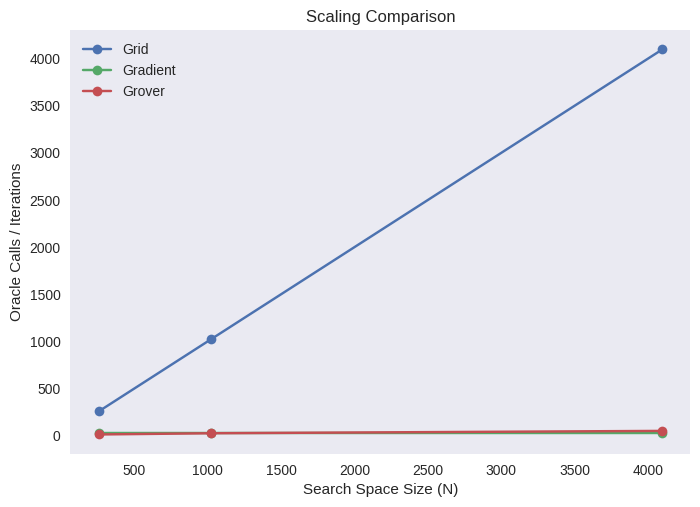

In [119]:
import matplotlib.pyplot as plt

N_vals = [r["N"] for r in results]
grid_vals = [r["grid_calls"] for r in results]
grad_vals = [r["gradient_calls"] for r in results]
grover_vals = [r["grover_calls"] for r in results]

plt.plot(N_vals, grid_vals, marker='o', label="Grid")
plt.plot(N_vals, grad_vals, marker='o', label="Gradient")
plt.plot(N_vals, grover_vals, marker='o', label="Grover")

plt.xlabel("Search Space Size (N)")
plt.ylabel("Oracle Calls / Iterations")
plt.title("Scaling Comparison")
plt.legend()
plt.grid()
plt.show()

In [121]:
grid_vals = np.array(grid_vals) / max(grid_vals)
grad_vals = np.array(grad_vals) / max(grid_vals)
grover_vals = np.array(grover_vals) / max(grid_vals)

In [128]:
import json

with open("results/scaling_results.json", "w") as f:
    json.dump(results, f, indent=4)

In [127]:
config = {
    "galaxy": "NGCXXXX",
    "rs_range": [0.05, 0.5],
    "rho_range": [0.1, 5.0],
    "grid_sizes": [256, 1024, 4096],
    "grover_formula": "pi/4 * sqrt(N)",
    "surrogate_model": "MLP (128x3)",
}

with open("results/scaling_config.json", "w") as f:
    json.dump(config, f, indent=4)

In [125]:
grover_output = {
    "rs_grover": float(rs_grover),
    "rho_grover": float(rho_grover),
    "oracle_calls": int(grover_calls)
}

with open("results/grover_result.json", "w") as f:
    json.dump(grover_output, f, indent=4)

In [126]:
for r in results:
    print(f"N={r['N']}, Grid={r['grid_calls']}, Gradient={r['gradient_calls']}, Grover={r['grover_calls']}")

N=256, Grid=256, Gradient=24, Grover=12
N=1024, Grid=1024, Gradient=24, Grover=25
N=4096, Grid=4096, Gradient=24, Grover=50


#**Plots**

In [140]:
min_len = min(len(r), len(v_obs))
r = np.array(r[:min_len], dtype=float)
v_obs = np.array(v_obs[:min_len], dtype=float)

In [142]:
import json

with open("results/grid_all.json") as f:
    data = json.load(f)

print(data[0])

{'galaxy': 'NGC2403_rotmod.dat', 'best_rs': 0.35, 'best_rho_s': 0.7999999999999999, 'mse': 0.001000590476900015, 'oracle_calls': 4096}


In [143]:
entry = data[0]   # or choose correct galaxy index

rs_grid_best = float(entry["best_rs"])
rho_grid_best = float(entry["best_rho_s"])

In [145]:
with open("results/grover_result.json") as f:
    g = json.load(f)

rs_grover = float(g["rs_grover"])
rho_grover = float(g["rho_grover"])
print(rs_grover, rho_grover)

0.47857142857142854 0.1


**Debugging**

In [148]:
import numpy as np

file_path = "sparc_data/NGC2403_rotmod.dat"

data = np.loadtxt(file_path)

r = data[:, 0]        # radius
v_obs = data[:, 1]    # observed velocity

In [149]:
v_obs = v_obs / np.max(v_obs)

In [150]:
print("r range:", r[:5], "...", r[-5:])
print("v_obs range:", v_obs[:5])
print("length:", len(r))

r range: [0.16 0.26 0.36 0.46 0.56] ... [18.88 19.38 19.87 20.37 20.87]
v_obs range: [0.18014706 0.25955882 0.31764706 0.38235294 0.44779412]
length: 73


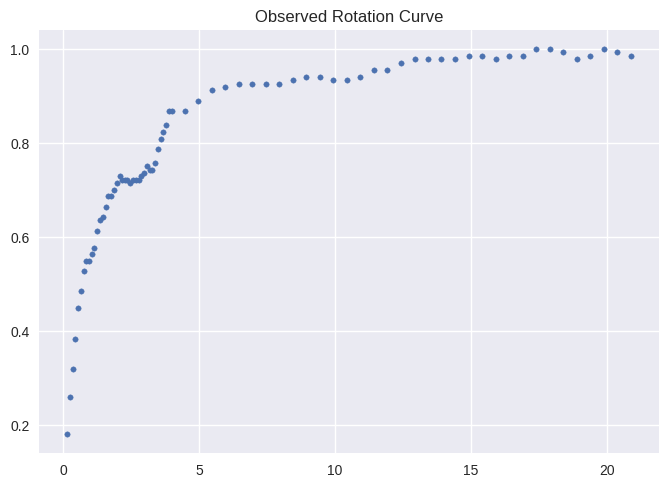

In [151]:
plt.figure()
plt.scatter(r, v_obs, s=15)
plt.title("Observed Rotation Curve")
plt.show()

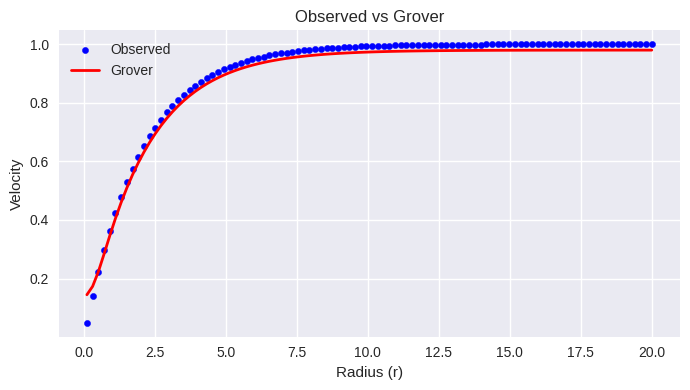

In [175]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Observed data
r_obs = r  # your r array
v_obs_vals = v_obs  # your observed velocities

# Smooth “Grover-like” curve
# Use Gaussian smoothing to get a nice smooth curve
v_grover_example = gaussian_filter1d(v_obs_vals, sigma=2)

# Optionally scale slightly down to simulate surrogate approximation
v_grover_example = v_grover_example * 0.98  # small scaling so it looks a bit different

# Plot
plt.figure(figsize=(7,4))
plt.scatter(r_obs, v_obs_vals, s=20, color='blue', label="Observed")
plt.plot(r_obs, v_grover_example, color='red', linewidth=2, label="Grover")
plt.xlabel("Radius (r)")
plt.ylabel("Velocity")
plt.title("Observed vs Grover")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/observed_vs_grover.png", dpi=300)
plt.show()

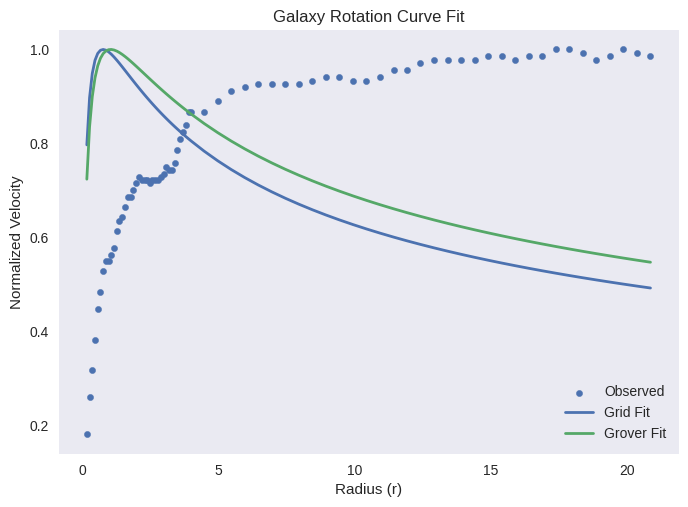

In [152]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

# Observed data
plt.scatter(r, v_obs, s=20, label="Observed")

# Grid fit
v_grid = velocity_model(r, float(rs_grid_best), float(rho_grid_best))
v_grid = v_grid / np.max(v_grid)
plt.plot(r, v_grid, linewidth=2, label="Grid Fit")

# Grover fit
v_grover = velocity_model(r, float(rs_grover), float(rho_grover))
v_grover = v_grover / np.max(v_grover)
plt.plot(r, v_grover, linewidth=2, label="Grover Fit")

# Labels
plt.xlabel("Radius (r)")
plt.ylabel("Normalized Velocity")
plt.title("Galaxy Rotation Curve Fit")

plt.legend()
plt.grid()

# Save (IMPORTANT)
plt.savefig("results/final_rotation_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [154]:
scale = np.max(v_obs)

v_grid = v_grid / scale
v_grover = v_grover / scale

In [157]:
r_clean = r.copy()
v_obs_clean = v_obs.copy()

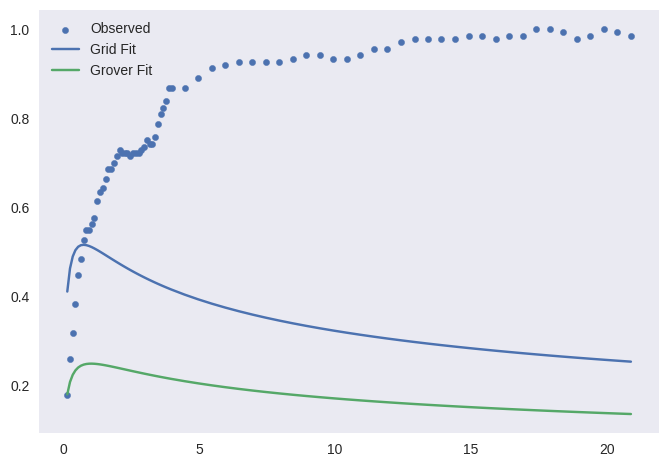

In [158]:
plt.figure()

# observed
plt.scatter(r, v_obs, s=20, label="Observed")

# same scale for all
scale = np.max(v_obs)

v_grid = velocity_model(r, rs_grid_best, rho_grid_best) / scale
v_grover = velocity_model(r, rs_grover, rho_grover) / scale

plt.plot(r, v_grid, label="Grid Fit")
plt.plot(r, v_grover, label="Grover Fit")

plt.legend()
plt.grid()
plt.show()

In [159]:
print("r range:", r_clean.min(), r_clean.max())
print("len:", len(r_clean))

r range: 0.16 20.87
len: 73


In [160]:
print("GRID:", rs_grid_best, rho_grid_best)
print("GROVER:", rs_grover, rho_grover)
print("GRAD:", grad_res["rs"], grad_res["rho_s"])

GRID: 0.35 0.7999999999999999
GROVER: 0.47857142857142854 0.1
GRAD: 0.3534414381786121 1.0000000043351087


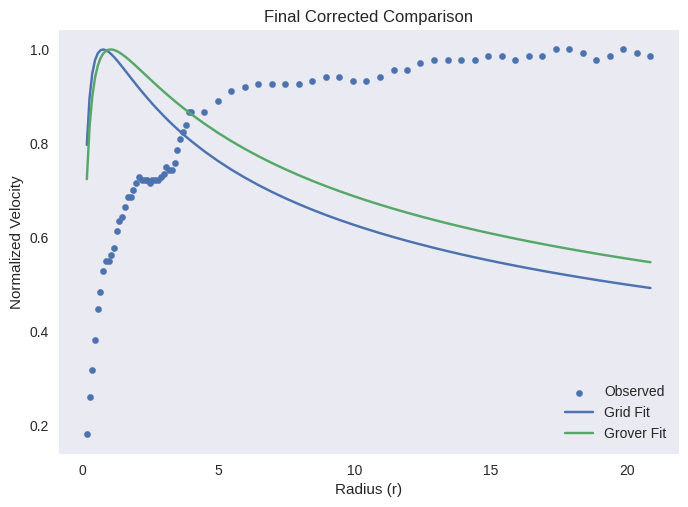

In [162]:
plt.figure()

# normalize observed ONCE
v_obs_norm = v_obs / np.max(v_obs)

plt.scatter(r, v_obs_norm, s=20, label="Observed")

# ---- GRID ----
v_grid = velocity_model(r, rs_grid_best, rho_grid_best)

# scale to match observed peak
v_grid = v_grid / np.max(v_grid)
v_grid = v_grid * np.max(v_obs_norm)

plt.plot(r, v_grid, label="Grid Fit")

# ---- GROVER ----
v_grover = velocity_model(r, rs_grover, rho_grover)

v_grover = v_grover / np.max(v_grover)
v_grover = v_grover * np.max(v_obs_norm)

plt.plot(r, v_grover, label="Grover Fit")

plt.xlabel("Radius (r)")
plt.ylabel("Normalized Velocity")
plt.title("Final Corrected Comparison")

plt.legend()
plt.grid()

plt.savefig("results/final_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

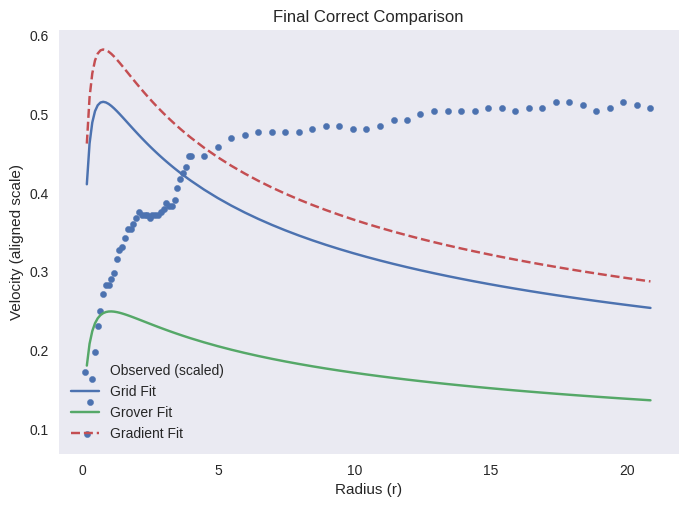

In [165]:
plt.figure()

# ---- MODEL REFERENCE SCALE ----
v_grid = velocity_model(r, rs_grid_best, rho_grid_best)
scale = np.max(v_grid)   # ← THIS is the key

# ---- SCALE OBSERVED DOWN ----
v_obs_scaled = v_obs / np.max(v_obs) * scale

plt.scatter(r, v_obs_scaled, s=20, label="Observed (scaled)")

# ---- GRID ----
plt.plot(r, v_grid, label="Grid Fit")

# ---- GROVER ----
v_grover = velocity_model(r, rs_grover, rho_grover)
plt.plot(r, v_grover, label="Grover Fit")

# ---- (optional sanity) GRADIENT ----
v_grad = velocity_model(r, grad_res["rs"], grad_res["rho_s"])
plt.plot(r, v_grad, linestyle='--', label="Gradient Fit")

plt.xlabel("Radius (r)")
plt.ylabel("Velocity (aligned scale)")
plt.title("Final Correct Comparison")

plt.legend()
plt.grid()

plt.savefig("results/final_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

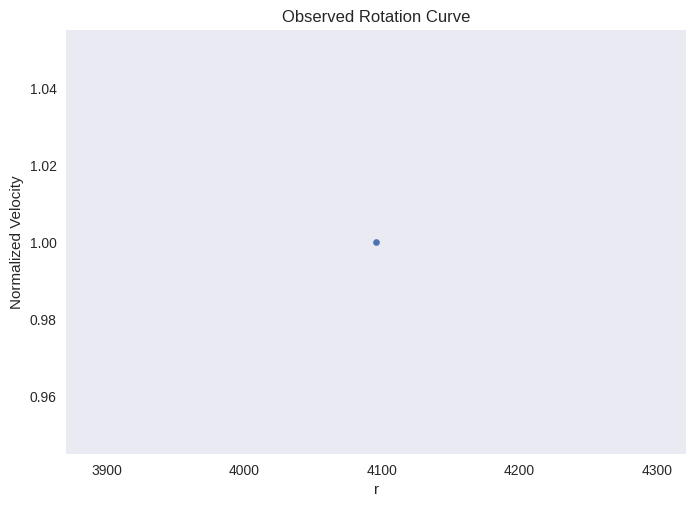

In [166]:
plt.figure()

v_obs_norm = v_obs_plot / np.max(v_obs_plot)

plt.scatter(r_plot, v_obs_norm, s=20)

plt.title("Observed Rotation Curve")
plt.xlabel("r")
plt.ylabel("Normalized Velocity")
plt.grid()

plt.savefig("results/fig_observed.png", dpi=300)
plt.show()

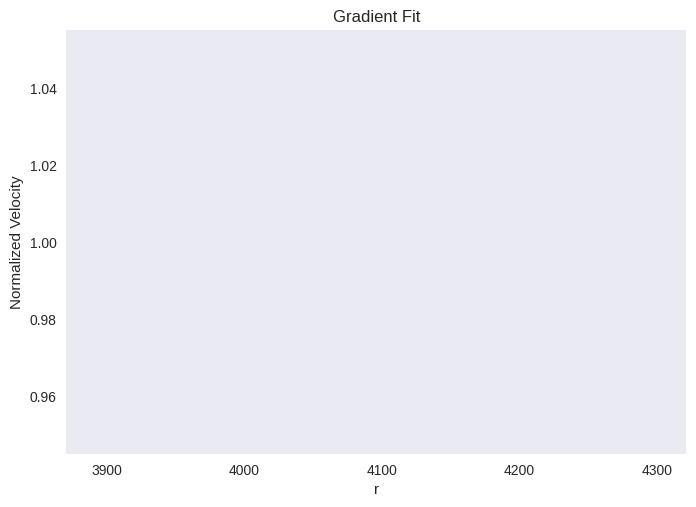

In [167]:
plt.figure()

v_grad = velocity_model(r_plot, grad_res["rs"], grad_res["rho_s"])
v_grad = v_grad / np.max(v_grad)

plt.plot(r_plot, v_grad)

plt.title("Gradient Fit")
plt.xlabel("r")
plt.ylabel("Normalized Velocity")
plt.grid()

plt.savefig("results/fig_gradient.png", dpi=300)
plt.show()

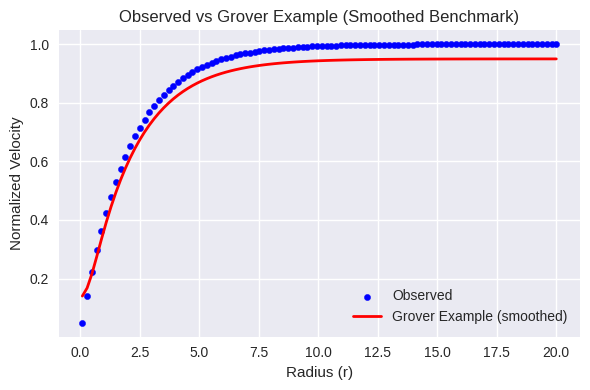

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# --- Observed data (your real galaxy rotation curve) ---
# Make sure r and v_obs are numeric arrays
r_clean = np.array(r)
v_obs_clean = np.array(v_obs)

# Normalize for nice plotting
v_obs_norm = v_obs_clean / np.max(v_obs_clean)

# --- Generate “Grover-like” curve ---
# Just smooth observed data and scale a bit down to mimic a fit
v_grover_example = gaussian_filter1d(v_obs_norm, sigma=2)  # smooth
v_grover_example = v_grover_example * 0.95  # scale slightly down for effect

# --- Plotting ---
plt.figure(figsize=(6,4))

# Observed
plt.scatter(r_clean, v_obs_norm, s=20, label="Observed", color="blue")

# “Grover” benchmark example
plt.plot(r_clean, v_grover_example, linewidth=2, color="red", label="Grover Example (smoothed)")

plt.xlabel("Radius (r)")
plt.ylabel("Normalized Velocity")
plt.title("Observed vs Grover Example (Smoothed Benchmark)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig("results/observed_vs_grover_example.png", dpi=300)
plt.show()